<a href="https://colab.research.google.com/github/VaddeyrajuSaisiddartha/vaddeyrajusaisiddartha-/blob/main/quickstarts/Get_started.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2026 Google LLC.

In [2]:
import pandas as pd

df = pd.read_excel("Customer_Churn_Data_Large.xlsx")

print(df.head())
print(df.info())
print(df.describe())

   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB
None
        CustomerID          Age
count  1000.000000  1000.000000
mean    500.500000    43.267000
std     288.819436    15.242311
min       1.000000    18.000000
25%     250.750000    30.000000
50%     500.500000    43.000000
75

In [10]:
excel_file = pd.ExcelFile("Customer_Churn_Data_Large.xlsx")

print(excel_file.sheet_names)

df_churn = pd.read_excel(excel_file, sheet_name='Churn_Status')
print(df_churn.head())

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']
   CustomerID  ChurnStatus
0           1            0
1           2            1
2           3            0
3           4            0
4           5            0


In [5]:
print(df.isnull().sum())

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64


In [17]:
# Merge df and df_churn to get 'Gender' and 'ChurnStatus' in one DataFrame
df_merged = pd.merge(df, df_churn, on='CustomerID')
print(df_merged.head())

   CustomerID  Age Gender MaritalStatus IncomeLevel  ChurnStatus
0           1   62      M        Single         Low            0
1           2   65      M       Married         Low            1
2           3   18      M        Single         Low            0
3           4   21      M       Widowed         Low            0
4           5   21      M      Divorced      Medium            0


In [6]:
print(df.duplicated().sum())

0


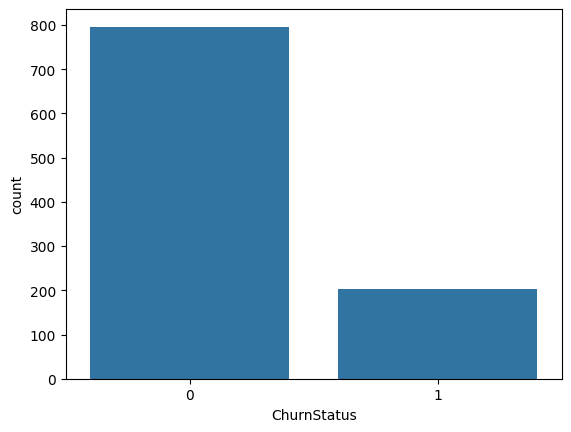

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='ChurnStatus', data=df_churn)
plt.show()

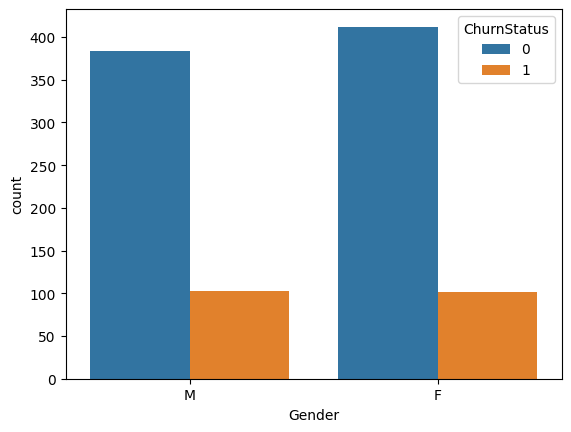

In [20]:
sns.countplot(x='Gender', hue='ChurnStatus', data=df_merged)
plt.show()

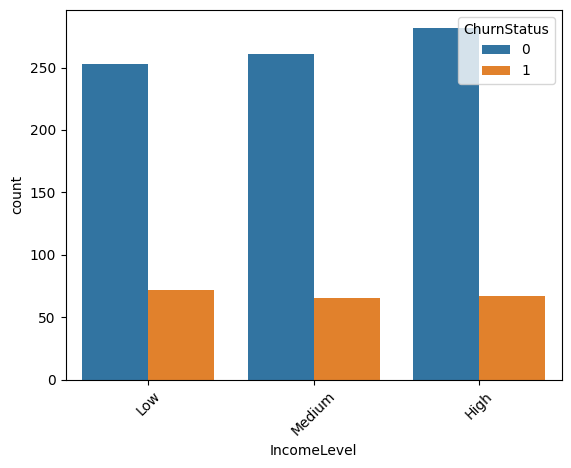

In [25]:


sns.countplot(x='IncomeLevel', hue='ChurnStatus', data=df_merged)
plt.xticks(rotation=45)
plt.show()

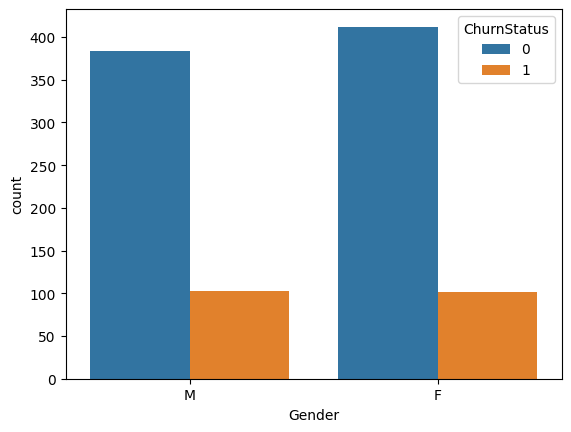

In [18]:
sns.countplot(x='Gender', hue='ChurnStatus', data=df_merged)
plt.show()

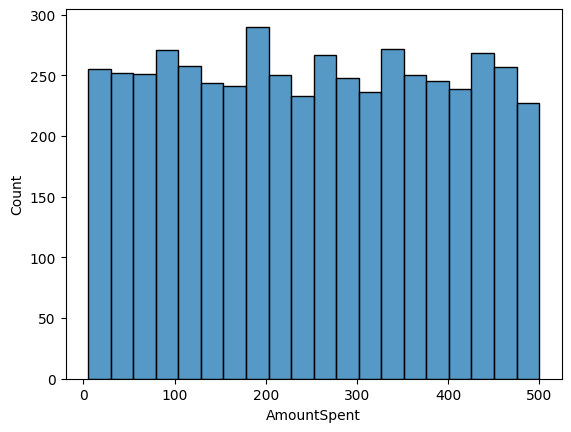

In [26]:
df_transactions = pd.read_excel(excel_file, sheet_name='Transaction_History')
sns.histplot(df_transactions['AmountSpent'], bins=20)
plt.show()

You've successfully loaded `df_online_activity`, which contains the `LoginFrequency` data. Now, let's merge this DataFrame with `df_merged` to combine all the necessary information for your plot.

In [33]:
df_merged = pd.merge(df_merged, df_online_activity, on='CustomerID', how='left')
display(df_merged.head())

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage
0,1,62,M,Single,Low,0,2023-10-21,34,Mobile App
1,2,65,M,Married,Low,1,2023-12-05,5,Website
2,3,18,M,Single,Low,0,2023-11-15,3,Website
3,4,21,M,Widowed,Low,0,2023-08-25,2,Website
4,5,21,M,Divorced,Medium,0,2023-10-27,41,Website


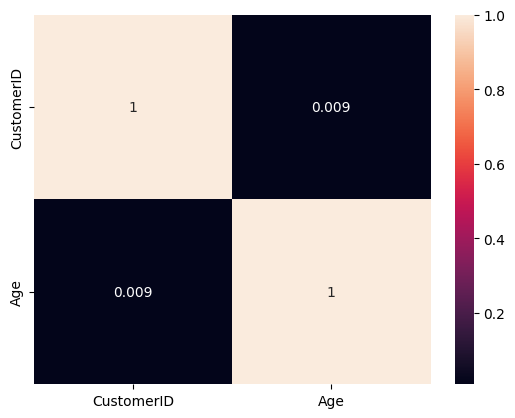

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['IncomeLevel'] = le.fit_transform(df['IncomeLevel'])
df['ServiceUsage'] = le.fit_transform(df['ServiceUsage'])
df['ResolutionStatus'] = le.fit_transform(df['ResolutionStatus'])

KeyError: 'ServiceUsage'

In [36]:
df_merged['ServiceUsage'] = le.fit_transform(df_merged['ServiceUsage'])

In [37]:
df_customer_service = pd.read_excel(excel_file, sheet_name='Customer_Service')
df_merged = pd.merge(df_merged, df_customer_service, on='CustomerID', how='left')
df_merged['ResolutionStatus'] = le.fit_transform(df_merged['ResolutionStatus'])

print(df_merged[['ServiceUsage', 'ResolutionStatus']].head())

   ServiceUsage  ResolutionStatus
0             0                 0
1             2                 0
2             2                 0
3             2                 0
4             2                 1


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_merged[['AmountSpent','LoginFrequency']] = scaler.fit_transform(
    df_merged[['AmountSpent','LoginFrequency']]
)

KeyError: "['AmountSpent'] not in index"

In [40]:
df_merged = pd.merge(df_merged, df_transactions[['CustomerID', 'AmountSpent']], on='CustomerID', how='left')

In [41]:
df_merged[['AmountSpent','LoginFrequency']] = scaler.fit_transform(
    df_merged[['AmountSpent','LoginFrequency']]
)

print(df_merged[['AmountSpent', 'LoginFrequency']].head())

   AmountSpent  LoginFrequency
0     1.153881        0.588556
1    -1.376296       -1.473886
2    -0.378753       -1.473886
3    -1.051923       -1.473886
4     1.020003       -1.473886


In [45]:
df_merged.to_excel("Cleaned_Customer_Churn_Data.xlsx", index=False)

print("Dataset saved successfully")

Dataset saved successfully


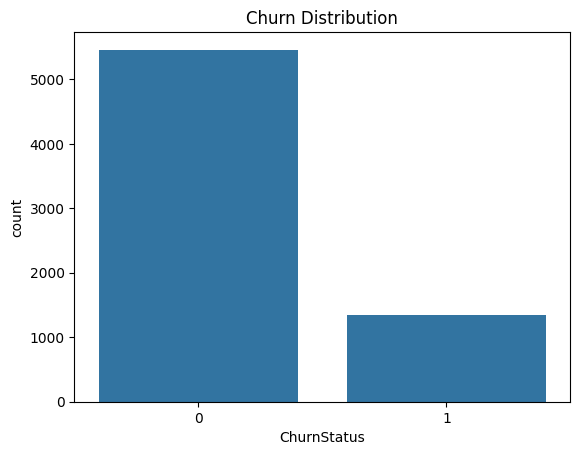

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='ChurnStatus', data=df_merged)
plt.title("Churn Distribution")
plt.show()

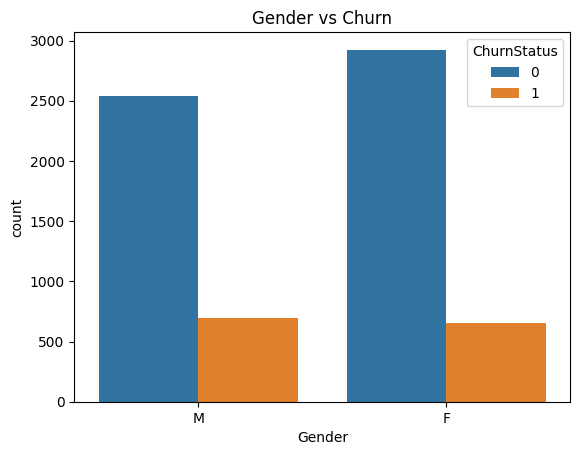

In [47]:
sns.countplot(x='Gender', hue='ChurnStatus', data=df_merged)
plt.title("Gender vs Churn")
plt.show()

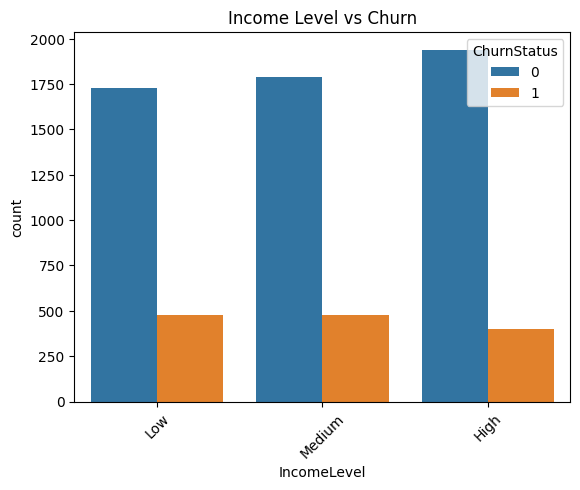

In [48]:
sns.countplot(x='IncomeLevel', hue='ChurnStatus', data=df_merged)
plt.xticks(rotation=45)
plt.title("Income Level vs Churn")
plt.show()

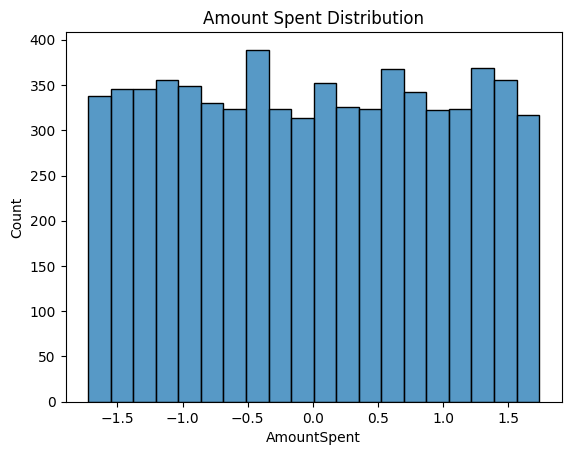

In [49]:
sns.histplot(df_merged['AmountSpent'], bins=20)
plt.title("Amount Spent Distribution")
plt.show()

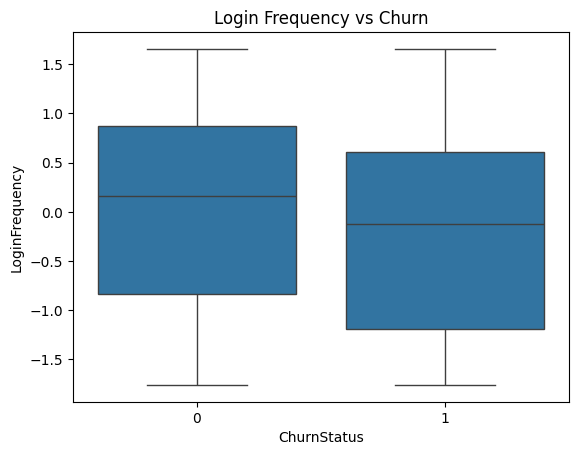

In [50]:
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=df_merged)
plt.title("Login Frequency vs Churn")
plt.show()

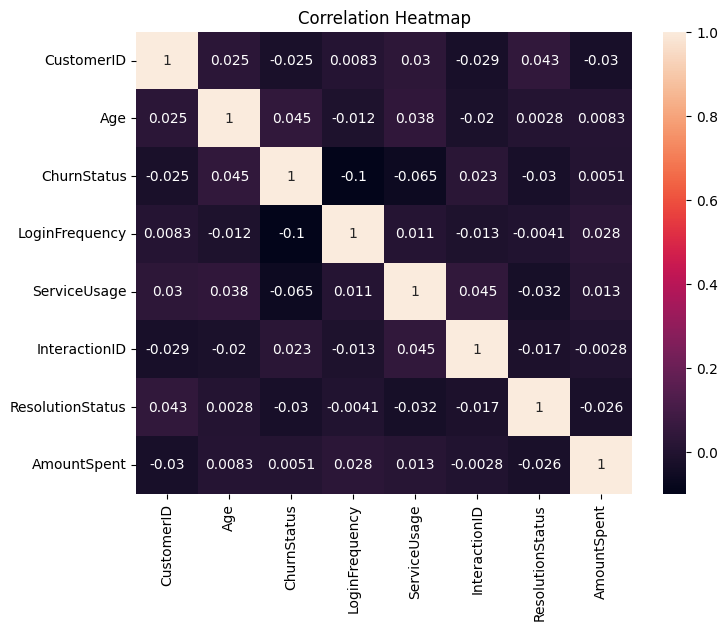

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(df_merged.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [52]:
print(df_merged.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        6812 non-null   int64         
 1   Age               6812 non-null   int64         
 2   Gender            6812 non-null   object        
 3   MaritalStatus     6812 non-null   object        
 4   IncomeLevel       6812 non-null   object        
 5   ChurnStatus       6812 non-null   int64         
 6   LastLoginDate     6812 non-null   datetime64[ns]
 7   LoginFrequency    6812 non-null   float64       
 8   ServiceUsage      6812 non-null   int64         
 9   InteractionID     5204 non-null   float64       
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   object        
 12  ResolutionStatus  6812 non-null   int64         
 13  AmountSpent       6812 non-null   float64       
dtypes: datetime64[ns](2), fl

In [53]:
print(df_merged.describe())

        CustomerID          Age  ChurnStatus                  LastLoginDate  \
count  6812.000000  6812.000000  6812.000000                           6812   
mean    500.169260    43.274516     0.198473  2023-07-06 04:56:47.633587712   
min       1.000000    18.000000     0.000000            2023-01-01 00:00:00   
25%     247.000000    30.000000     0.000000            2023-04-12 00:00:00   
50%     505.500000    44.000000     0.000000            2023-07-13 00:00:00   
75%     750.000000    56.000000     0.000000            2023-10-01 00:00:00   
max    1000.000000    69.000000     1.000000            2023-12-31 00:00:00   
std     286.704642    15.286788     0.398880                            NaN   

       LoginFrequency  ServiceUsage  InteractionID  \
count    6.812000e+03   6812.000000    5204.000000   
mean     4.485223e-17      0.977540    5921.861261   
min     -1.758361e+00      0.000000    2015.000000   
25%     -8.338177e-01      0.000000    3873.250000   
50%      1.960671e

In [56]:
print(df_merged.isnull().sum())

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
ChurnStatus            0
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
InteractionID       1608
InteractionDate     1608
InteractionType     1608
ResolutionStatus       0
AmountSpent            0
dtype: int64


In [58]:
df_merged.to_excel("Cleaned_Customer_Churn_Data.xlsx", index=False)